# 01 · Exploratory Data Analysis

Understanding the spatio-temporal structure of the traffic-demand dataset.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')
print('train', train.shape, '| test', test.shape)
train.head()

train (77299, 11) | test (41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## Target distribution
Demand is heavily right-skewed and near-zero-inflated → motivates log-space training.

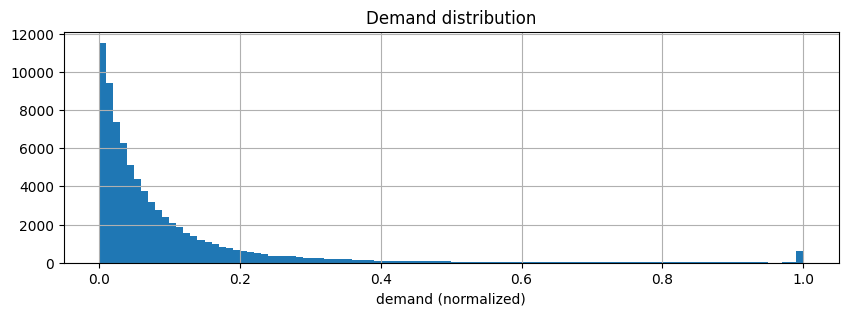

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [2]:
ax = train['demand'].hist(bins=100, figsize=(10,3))
plt.title('Demand distribution'); plt.xlabel('demand (normalized)'); plt.show()
print(train['demand'].describe())

## Temporal coverage
Train = one full reference day + early hours of the next; test = the next day's daytime.

In [3]:
def mod(t):
    h,m=str(t).split(':'); return int(h)*60+int(m)
for d in (train,test): d['slot']=d['timestamp'].map(mod)//15
print('train days:', sorted(train.day.unique()), '| test days:', sorted(test.day.unique()))
print('test slot range:', test.slot.min(), '-', test.slot.max())

train days: [np.int64(48), np.int64(49)] | test days: [np.int64(49)]
test slot range: 9 - 55


## Time-of-day profile (the core signal)
Average demand by 15-minute slot — the smooth daily shape the model exploits.

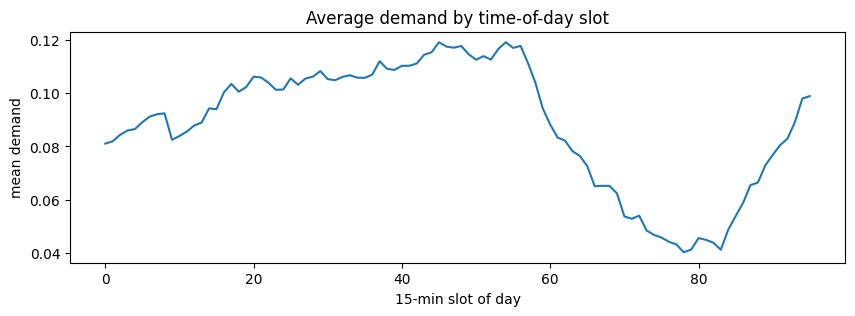

In [4]:
prof = train.groupby('slot')['demand'].mean()
prof.plot(figsize=(10,3), title='Average demand by time-of-day slot')
plt.xlabel('15-min slot of day'); plt.ylabel('mean demand'); plt.show()

## Spatial structure
Geohashes decode to a compact region; nearby locations behave similarly (→ geo-clusters).

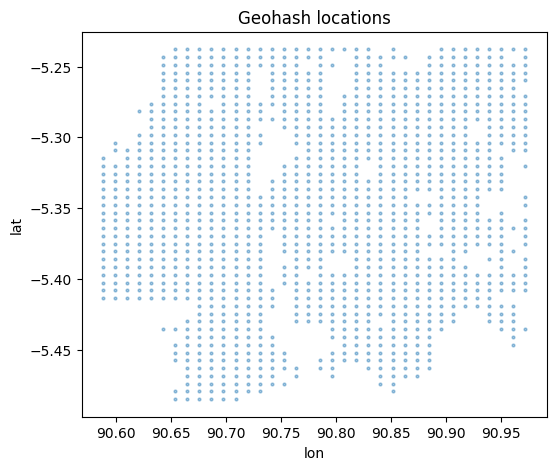

unique geohashes: 1249


In [5]:
# geohash decode (base-32) -> lat/lon
_B32='0123456789bcdefghjkmnpqrstuvwxyz'; _DEC={c:i for i,c in enumerate(_B32)}
def gh_dec(g):
    lat,lon,lo=[-90.,90.],[-180.,180.],True
    for ch in str(g).lower():
        cd=_DEC.get(ch)
        if cd is None: continue
        for mk in (16,8,4,2,1):
            if lo: m=(lon[0]+lon[1])/2; lon[0 if cd&mk else 1]=m
            else:  m=(lat[0]+lat[1])/2; lat[0 if cd&mk else 1]=m
            lo=not lo
    return (sum(lat)/2, sum(lon)/2)
gh = train['geohash'].unique()
ll = np.array([gh_dec(g) for g in gh])
plt.figure(figsize=(6,5)); plt.scatter(ll[:,1], ll[:,0], s=4, alpha=.4)
plt.title('Geohash locations'); plt.xlabel('lon'); plt.ylabel('lat'); plt.show()
print('unique geohashes:', len(gh))